# Chapter 05: Fine-tuning for classification
## 5.1 Fine-Tuning on LLMs

In chapter 04, we implemented a pre-training process for an LLM.

For many reasons, we expect a model that focuses on specific aspects such as classification tasks, sentence generation or answering questions. This requires new datasets and a training process for **fine-tuning**.
- Pre-train provides basic ability for LLMs to understand and generate texts.
- Fine-tuning makes LLMs specialize in some aspects or tasks.

In this chapter, we focus on fine-tuning a model for an email-classification task.
- This is a basic task in machine learning. You may achieve it in some other ways, such as a Bayes classifier, logistic regression, and so on.
- We can think of a classification-finetuned model as a very specialized model; in practice, it is much easier to create a specialized model than a generalist model that performs well on many different tasks.

## 5.2 Prepare the dataset

First, we download and unzip the dataset.
- [UCI](https://archive.ics.uci.edu/) in the `url` is a popular open dataset website for machine learning.
    - The dataset we choose contains samples of spam and ham texts.
- You should see `sms_spam_collection/` after running the code.

In [1]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path

import requests
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = data_path("sms_spam_collection.zip")
extracted_path = data_path("sms_spam_collection")
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

# make sure the download/extraction targets exist (data/ is not tracked by git)
Path(extracted_path).mkdir(parents=True, exist_ok=True)
Path(zip_path).parent.mkdir(parents=True, exist_ok=True)

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

/home/shiiyu/Projects/LLMs/data/sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


You can run the following code to see how the `tsv` file works.

In [2]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
# print the file
print(df)
# count the labels
print(df["Label"].value_counts())

     Label                                               Text
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham               Will ü b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name

[5572 rows x 2 columns]
Label
ham     4825
spam     747
Name: count, dtype: int64


The spam and ham counts differ, so we need to balance their numbers for simplicity.

In [3]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=325)
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


This is a **binary classification task**, so we have to change these labels to $0$ and $1$.
- $0$ represents `ham`.
- $1$ represents `spam`.

In [4]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
print(balanced_df)

      Label                                               Text
537       0  Probably gonna be here for a while, see you la...
1678      0           Lol where do u come up with these ideas?
1775      0  Its ok chikku, and its my 1 of favourite song....
4568      0  But you were together so you should be thinkin...
3791      0  I love you !!! You know? Can you feel it? Does...
...     ...                                                ...
5537      1  Want explicit SEX in 30 secs? Ring 02073162414...
5540      1  ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547      1  Had your contract mobile 11 Mnths? Latest Moto...
5566      1  REMINDER FROM O2: To get 2.50 pounds free call...
5567      1  This is the 2nd time we have tried 2 contact u...

[1494 rows x 2 columns]


Finally, we randomly divide the dataset into training, validation and test subsets.

In [5]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # split the dataset
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

# [train:validation:test] = [0.7:0.1:0.2]
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
train_df.to_csv(data_path("train.csv"), index=None)
validation_df.to_csv(data_path("validation.csv"), index=None)
test_df.to_csv(data_path("test.csv"), index=None)

You should see 3 `csv` files in the `data/` directory.

## 5.3 Create data loaders

These text messages have different lengths. For batch training, there are two choices.
1. Truncate all messages to the length of the shortest message in the dataset or batch.
2. Pad all messages to the length of the longest message in the dataset or batch.

We choose option 2 and pad all messages to the longest message in the dataset with the special padding token `<|endoftext|>`.
- In the `gpt2` tokenizer, `<|endoftext|>` is encoded as `50256`.

In [6]:
import tiktoken
import torch
from torch.utils.data import Dataset

tokenizer = tiktoken.get_encoding("gpt2")
# print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, # when max_length=None, it equals to the length of the longest sample 
                 pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # pre-tokenize texts
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # truncate sequences if they are longer than max_length, only when max_length=True
            self.encoded_texts = [encoded_text[:self.max_length] 
                                  for encoded_text in self.encoded_texts]

        # pad sequences to the longest sequence
        self.encoded_texts = [encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) 
                              for encoded_text in self.encoded_texts]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (torch.tensor(encoded, dtype=torch.long),torch.tensor(label, dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [7]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
train_dataset = SpamDataset(
    csv_file=data_path("train.csv"),
    max_length=None,
    tokenizer=tokenizer
)

val_dataset = SpamDataset(
    csv_file=data_path("validation.csv"),
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file=data_path("test.csv"),
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

Next, we use the dataset to instantiate the data loaders.

In [8]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(325)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

For a batch, there are 8 samples with the longest length after padding.

In [9]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

# confirm the shape of batchs
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

# confirm the length of three datasets
print(f"\n{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

Train loader:
Input batch dimensions: torch.Size([8, 188])
Label batch dimensions torch.Size([8])

130 training batches
19 validation batches
38 test batches


## 5.4 Initialize the model with pretrained weights

We initialize the pretrained model we worked with in chapter 04.

In [10]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [11]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
import triton # IMPORTANT: if you meet any errors in section 5.7, unannotate this line
from utils.gpt_download import download_and_load_gpt2
from utils.previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir=str(repo_path("gpt2")))

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

I0000 00:00:1789286858.769232  107442 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789286858.803296  107442 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789286859.445918  107442 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789286859.446118  107442 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU

File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/checkpoint
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/encoder.json
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/hparams.json
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/model.ckpt.index
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: /home/shiiyu/Projects/LLMs/gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

Without fine-tuning, let's see if the model can classify spam messages via **prompting**.

In [12]:
from utils.previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

torch.seed()

text_test = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_test, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


## 5.5 Add a classification head

The original GPT model has the output layer mapping $768$ hidden units into $50257$ units. For fine-tuning, we expect the output layer to only contain 2 units representing $0$ or $1$.
- Our final goal is to replace and finetune the output layer. 

![Add a classification head](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/09.webp)

In [13]:
num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

It's crucial to decide which parameters should be trained during the fine-tuning process.
- In this chapter, we make the last transformer block, final `LayerNorm` and new output layer trainable.

In [14]:
for param in model.parameters():
    param.requires_grad = False

for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

for param in model.out_head.parameters():
    param.requires_grad = True

Let's try to give it some inputs. 

In [15]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0) # shape: (batch_size, num_tokens)

with torch.no_grad():
    outputs = model(inputs) # shape: (batch_size, num_tokens, num_classes=2)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[ 1.3308, -0.7917],
         [ 2.1181, -4.1232],
         [ 1.9988, -3.6032],
         [ 2.5662, -1.9270]]])
Outputs dimensions: torch.Size([1, 4, 2])


According to the causal attention mechanism, the output corresponding to the last token contains the most information about all other tokens (the only one).
- Thus, we should only focus on the last output with 2 dimensions.

In [16]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[ 2.5662, -1.9270]])


## 5.6 Calculate loss and accuracy

With the last output token, we've got a $1\times 2$ tensor for binary classification.
- First, we convert them via softmax.
- Then, we use `argmax` to get the predicted label $0$ or $1$.
- Finally, we calculate the loss and accuracy for the next step.

In [17]:
logits = outputs[:, -1, :]
print("Logits:", logits)
label = torch.argmax(logits)
print("Class label:", label.item())

Logits: tensor([[ 2.5662, -1.9270]])
Class label: 0


In [18]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            # calculate the labels
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

Now let's calculate these metrics. 

In [19]:
# choose proper device for calculating
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)
model.to(device) 

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Device: cuda
Training accuracy: 50.00%
Validation accuracy: 55.00%
Test accuracy: 51.25%


Before we finetune the model for higher accuracy, here are some notes.
- The loss function is needed for optimization during the fine-tuning.
    - The cross-entropy loss function is an ideal choice.
- Our goal is to maximize the spam classification accuracy of the model.
    - This is equivalent to minimizing the loss function.
- We should create a loss calculation loader for data loaders.
- The following process for calculating losses doesn't train the model.

In [20]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

# this is same as one in chapter 04
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

with torch.no_grad(): # disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 1.976
Validation loss: 2.650
Test loss: 2.891


## 5.7 Fine-tuning on supervised data

Before we continue, there is one thing to keep in mind.
- In the pretraining process, we use a lot of unlabeled data.
    - This is an **unsupervised** learning process.
    - It makes the model learn from a huge number of natural language texts.
    - All parameters are trainable during this process.
- In the fine-tuning process, we use specific data with labels.
    - This is a **supervised** learning process.
    - Only specific parameters are trainable during this process.

The following function trains (finetunes) the model for lower loss and higher accuracy.

In [21]:
# see more annotation details of train function in chapter 04
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0] # changed: track examples instead of tokens
            global_step += 1

            # optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

Take a few minutes' break while running the following code~
- If you encounter any errors, please try to import `triton` in section 5.4
    - This usually happens when `tensorflow` and `triton` crash.

In [22]:
import time

start_time = time.time()

# see if you want a fixed random seed
# torch.manual_seed(325)
torch.seed()

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.688, Val loss 2.463
Ep 1 (Step 000050): Train loss 0.701, Val loss 0.699
Ep 1 (Step 000100): Train loss 0.532, Val loss 0.537
Training accuracy: 80.00% | Validation accuracy: 92.50%
Ep 2 (Step 000150): Train loss 0.374, Val loss 0.368
Ep 2 (Step 000200): Train loss 0.259, Val loss 0.187
Ep 2 (Step 000250): Train loss 0.360, Val loss 0.084
Training accuracy: 92.50% | Validation accuracy: 95.00%
Ep 3 (Step 000300): Train loss 0.048, Val loss 0.065
Ep 3 (Step 000350): Train loss 0.196, Val loss 0.040
Training accuracy: 92.50% | Validation accuracy: 97.50%
Ep 4 (Step 000400): Train loss 0.063, Val loss 0.036
Ep 4 (Step 000450): Train loss 0.018, Val loss 0.032
Ep 4 (Step 000500): Train loss 0.072, Val loss 0.027
Training accuracy: 97.50% | Validation accuracy: 100.00%
Ep 5 (Step 000550): Train loss 0.089, Val loss 0.021
Ep 5 (Step 000600): Train loss 0.033, Val loss 0.028
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 1.34 mi

We can visualize the results below.

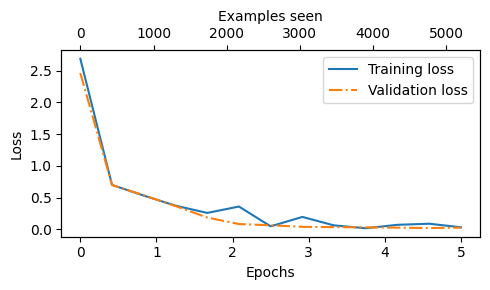

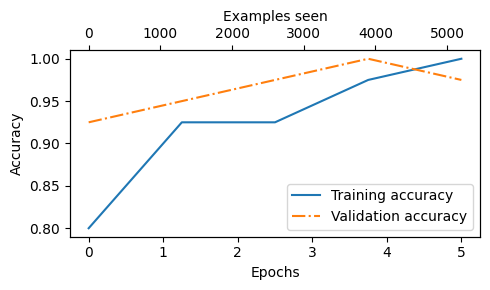

In [23]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    # plt.savefig(f"{label}-plot.pdf")
    plt.show()

# plot loss curve
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

# plot acc curve
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

We can compute the training, validation, and test set performances over the entire dataset as follows.

In [25]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 98.08%
Validation accuracy: 99.33%
Test accuracy: 96.67%


## 5.8 Complete an LLM classifier

Now, we can implement a function using the finetuned model for classification.

In [26]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]

    # truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )    

    # pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()

    # return the classified result
    return "spam" if predicted_label == 1 else "not spam"

We can feed some messages into the model.

In [27]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print("text1:", classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length))
print("text2:",classify_review(text_2, model, tokenizer, device, max_length=train_dataset.max_length))

text1: spam
text2: not spam


Finally, we should save the model for the next use.

In [28]:
import sys
from pathlib import Path
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "utils" / "paths.py").exists():
        sys.path.append(str(_p)); break
else:
    raise RuntimeError("repository root not found; start Jupyter inside the repo")
from utils.paths import data_path, repo_path
torch.save(model.state_dict(), repo_path("ch05", "review_classifier.pth"))

# 5.9 Create a local UI server

In this bonus section, a UI server is implemented with `chainlit`.
- You can interact with the classifier model like general GPT apps.
- Make sure you have installed `chainlit` and downloaded `app.py` from [GitHub](https://github.com/rasbt/LLMs-from-scratch/blob/main/ch06/04_user_interface/app.py); it lives in `ch05/` here.
- This creates a local address in your browser address bar, usually `http://localhost:8000`.

Execute the following command from the terminal to start.
```bash
chainlit run app.py
```

You can also apply this on other models.